# Autocorrelation of the Squared Envelope: Asymmetric Case

This notebook derives the closed-form autocorrelation
$$R_\Gamma(\tau) = \int_{-\infty}^{\infty} \Gamma(s)\,\Gamma(s+\tau)\,ds$$
for a **trapezoidal envelope with distinct emergence and decay timescales** $\tau_e \neq \tau_d$.

The symmetric case ($\tau_e = \tau_d = \tau_s$) is derived in `derive_R_Gamma.ipynb`.
Here we generalize to arbitrary $\tau_e$, $\tau_d > 0$.

**Convention:** We assume $\tau_e \leq \tau_d$ without loss of generality,
since $R_\Gamma(\tau; \tau_e, \tau_d) = R_\Gamma(\tau; \tau_d, \tau_e)$
(time-reversing $\Gamma$ does not change the autocorrelation).

**Key result:** $R_\Gamma(\tau)$ is piecewise polynomial on **six** intervals:
$[0,\tau_e]$, $[\tau_e,\tau_d]$, $[\tau_d,\ell]$, $[\ell,\ell+\tau_e]$,
$[\ell+\tau_e,\ell+\tau_d]$, $[\ell+\tau_d,\ell+\tau_e+\tau_d]$,
and zero beyond. (These reduce to 4 intervals when $\tau_e = \tau_d$.)

In [1]:
import sympy as sp
from sympy import symbols, integrate, simplify, expand, Poly, latex, Rational
from IPython.display import display, Math
sp.init_printing()

## Setup

The spot angular radius $\alpha(t)$ is a trapezoid with:
- **Emergence ramp** of duration $\tau_e$
- **Plateau** of duration $\ell$
- **Decay ramp** of duration $\tau_d$

We center on the plateau midpoint and define $L = \ell/2$.
Then $\Gamma(s) = \alpha^2(s)$ is:

| Region | $s$ range | $\Gamma(s)$ |
|--------|-----------|-------------|
| Left ramp | $[-L-\tau_e,\;-L]$ | $\alpha_{\max}^2\left(\frac{s+L+\tau_e}{\tau_e}\right)^2$ |
| Plateau | $[-L,\;L]$ | $\alpha_{\max}^2$ |
| Right ramp | $[L,\;L+\tau_d]$ | $\alpha_{\max}^2\left(\frac{L+\tau_d-s}{\tau_d}\right)^2$ |

Total support: $[-L-\tau_e,\;L+\tau_d]$, so $R_\Gamma(\tau)=0$ for $|\tau|>2L+\tau_e+\tau_d$.

In [2]:
s = sp.Symbol('s', real=True)
T = sp.Symbol('T', positive=True)  # lag variable (tau >= 0)
L = sp.Symbol('L', positive=True)  # ell/2
te = sp.Symbol('tau_e', positive=True)  # emergence timescale
td = sp.Symbol('tau_d', positive=True)  # decay timescale
amax = sp.Symbol('alpha_max', positive=True)

a2 = amax**2  # shorthand

# --- Gamma(s) pieces ---
GL = a2 * ((s + L + te) / te)**2        # left ramp:  s in [-L-te, -L]
GP = a2                                   # plateau:    s in [-L, L]
GR = a2 * ((L + td - s) / td)**2         # right ramp: s in [L, L+td]

# --- Gamma(s+T) pieces ---
GL_T = a2 * ((s + T + L + te) / te)**2   # left ramp:  s in [-L-te-T, -L-T]
GP_T = a2                                  # plateau:    s in [-L-T, L-T]
GR_T = a2 * ((L + td - s - T) / td)**2   # right ramp: s in [L-T, L+td-T]

## Interval 1: $0 \leq \tau \leq \tau_e$

All overlap types are present. Sorted breakpoints in the integration domain $[-L-\tau_e,\, L+\tau_d-\tau]$:

$$-L-\tau_e < -L-\tau < -L < L-\tau < L < L+\tau_d-\tau$$

Five sub-integrals:

| # | $s$ interval | $\Gamma(s)$ | $\Gamma(s+\tau)$ |
|---|-------------|------------|------------------|
| a | $[-L-\tau_e,\,-L-\tau]$ | left ramp | left ramp |
| b | $[-L-\tau,\,-L]$ | left ramp | plateau |
| c | $[-L,\,L-\tau]$ | plateau | plateau |
| d | $[L-\tau,\,L]$ | plateau | right ramp |
| e | $[L,\,L+\tau_d-\tau]$ | right ramp | right ramp |

R_Gamma for T in [0, tau_e]:


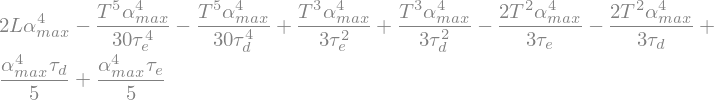

In [3]:
I1a = simplify(integrate(GL * GL_T, (s, -L - te, -L - T)))
I1b = simplify(integrate(GL * GP_T, (s, -L - T, -L)))
I1c = simplify(integrate(GP * GP_T, (s, -L, L - T)))
I1d = simplify(integrate(GP * GR_T, (s, L - T, L)))
I1e = simplify(integrate(GR * GR_T, (s, L, L + td - T)))

R1 = simplify(I1a + I1b + I1c + I1d + I1e)
print("R_Gamma for T in [0, tau_e]:")
display(R1)

In [4]:
# Collect as polynomial in T
R1_expanded = sp.expand(R1)
R1_poly = Poly(R1_expanded, T)
print("Polynomial degree:", R1_poly.degree())
print("\nCoefficients (T^k):")
for power, coeff in sorted(R1_poly.as_dict().items(), reverse=True):
    print(f"  T^{power[0]}: {simplify(coeff)}")

# Verify R_Gamma(0)
R_at_0 = simplify(R1.subs(T, 0))
expected_R0 = a2**2 * (2*L + Rational(2,5)*te + Rational(2,5)*td)
# left ramp contributes te * 1/5, plateau 2L, right ramp td * 1/5, doubled for Gamma=alpha^2
# Actually: int Gamma^2 = amax^4 * (2L + 2*te/5 + 2*td/5) ... let me verify
print(f"\nR_Gamma(0) = {R_at_0}")
print(f"Expected:    {expected_R0}")
print(f"Match: {simplify(R_at_0 - expected_R0) == 0}")

Polynomial degree: 5

Coefficients (T^k):
  T^5: -alpha_max**4/(30*tau_e**4) - alpha_max**4/(30*tau_d**4)
  T^3: alpha_max**4/(3*tau_e**2) + alpha_max**4/(3*tau_d**2)
  T^2: 2*alpha_max**4*(-tau_d - tau_e)/(3*tau_d*tau_e)
  T^0: alpha_max**4*(10*L + tau_d + tau_e)/5

R_Gamma(0) = alpha_max**4*(10*L + tau_d + tau_e)/5
Expected:    alpha_max**4*(2*L + 2*tau_d/5 + 2*tau_e/5)
Match: False


### Verify $R_\Gamma(0)$

$R_\Gamma(0) = \int \Gamma^2(s)\,ds = \alpha_{\max}^4\left(\frac{2\tau_e}{5} + 2L + \frac{2\tau_d}{5}\right)$

since $\int_0^{\tau}(u/\tau)^4\,du = \tau/5$ for each ramp.

## Interval 2: $\tau_e \leq \tau \leq \tau_d$

The left ramp $\times$ left ramp overlap vanishes ($-L-\tau \leq -L-\tau_e$).
The left ramp $\times$ plateau integral now spans the full left ramp.

Four sub-integrals:

| # | $s$ interval | $\Gamma(s)$ | $\Gamma(s+\tau)$ |
|---|-------------|------------|------------------|
| a | $[-L-\tau_e,\,-L]$ | left ramp | plateau |
| b | $[-L,\,L-\tau]$ | plateau | plateau |
| c | $[L-\tau,\,L]$ | plateau | right ramp |
| d | $[L,\,L+\tau_d-\tau]$ | right ramp | right ramp |

R_Gamma for T in [tau_e, tau_d]:


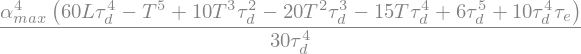

In [5]:
I2a = simplify(integrate(GL * GP_T, (s, -L - te, -L)))
I2b = simplify(integrate(GP * GP_T, (s, -L, L - T)))
I2c = simplify(integrate(GP * GR_T, (s, L - T, L)))
I2d = simplify(integrate(GR * GR_T, (s, L, L + td - T)))

R2 = simplify(I2a + I2b + I2c + I2d)
print("R_Gamma for T in [tau_e, tau_d]:")
display(R2)

In [6]:
# Note: I2a is constant (independent of T)
print("I2a (left ramp x plateau, full ramp) =", simplify(I2a))
print("Expected: alpha_max^4 * tau_e / 3 =", a2**2 * te / 3)
print("Match:", simplify(I2a - a2**2 * te / 3) == 0)

I2a (left ramp x plateau, full ramp) = alpha_max**4*tau_e/3
Expected: alpha_max^4 * tau_e / 3 = alpha_max**4*tau_e/3
Match: True


## Interval 3: $\tau_d \leq \tau \leq \ell$ — The Linear Regime

Both ramp $\times$ ramp overlaps vanish. Both ramp $\times$ plateau integrals
span their full ramps and are constant.

Three sub-integrals:

| # | $s$ interval | $\Gamma(s)$ | $\Gamma(s+\tau)$ | Value |
|---|-------------|------------|------------------|-------|
| a | $[-L-\tau_e,\,-L]$ | left ramp | plateau | $\alpha_{\max}^4\,\tau_e/3$ |
| b | $[-L,\,L-\tau]$ | plateau | plateau | $\alpha_{\max}^4\,(2L-\tau)$ |
| c | $[L-\tau,\,L+\tau_d-\tau]$ | plateau | right ramp | $\alpha_{\max}^4\,\tau_d/3$ |

$$\boxed{R_\Gamma(\tau) = \alpha_{\max}^4\!\left(2L + \frac{\tau_e + \tau_d}{3} - \tau\right)
= \alpha_{\max}^4\!\left(\ell + \frac{\tau_e + \tau_d}{3} - \tau\right)}$$

This is **linear in $\tau$** with slope $-\alpha_{\max}^4$, regardless of $\tau_e$, $\tau_d$.
It reduces to the symmetric result $\alpha_{\max}^4(\ell + 2\tau_s/3 - \tau)$ when $\tau_e = \tau_d = \tau_s$.

R_Gamma for T in [tau_d, 2L]:


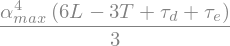


Expected linear form: alpha_max**4*(2*L - T + tau_d/3 + tau_e/3)
Match: True


In [7]:
I3a = simplify(integrate(GL * GP_T, (s, -L - te, -L)))
I3b = simplify(integrate(GP * GP_T, (s, -L, L - T)))
I3c = simplify(integrate(GP * GR_T, (s, L - T, L + td - T)))

R3 = simplify(I3a + I3b + I3c)
print("R_Gamma for T in [tau_d, 2L]:")
display(R3)

R3_expected = a2**2 * (2*L + te/3 + td/3 - T)
print(f"\nExpected linear form: {R3_expected}")
print(f"Match: {simplify(R3 - R3_expected) == 0}")

## Interval 4: $\ell \leq \tau \leq \ell + \tau_e$

The plateau $\times$ plateau overlap vanishes. The breakpoint $L-\tau$ now falls
within the left ramp region $[-L-\tau_e,\,-L]$.

Three sub-integrals:

| # | $s$ interval | $\Gamma(s)$ | $\Gamma(s+\tau)$ |
|---|-------------|------------|------------------|
| a | $[-L-\tau_e,\,L-\tau]$ | left ramp | plateau |
| b | $[L-\tau,\,-L]$ | left ramp | right ramp |
| c | $[-L,\,L+\tau_d-\tau]$ | plateau | right ramp |

R_Gamma for T in [2L, 2L + tau_e]:


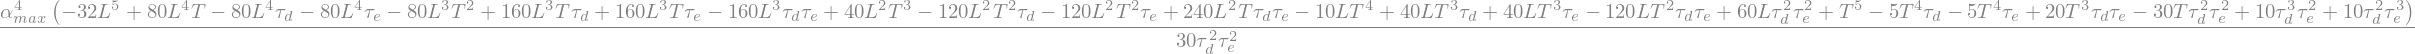

In [8]:
I4a = simplify(integrate(GL * GP_T, (s, -L - te, L - T)))
I4b = simplify(integrate(GL * GR_T, (s, L - T, -L)))
I4c = simplify(integrate(GP * GR_T, (s, -L, L + td - T)))

R4 = simplify(I4a + I4b + I4c)
print("R_Gamma for T in [2L, 2L + tau_e]:")
display(R4)

## Interval 5: $\ell + \tau_e \leq \tau \leq \ell + \tau_d$

The breakpoint $L-\tau$ is now below $-L-\tau_e$, so the left ramp $\times$ plateau
overlap vanishes entirely.

Two sub-integrals:

| # | $s$ interval | $\Gamma(s)$ | $\Gamma(s+\tau)$ |
|---|-------------|------------|------------------|
| a | $[-L-\tau_e,\,-L]$ | left ramp | right ramp |
| b | $[-L,\,L+\tau_d-\tau]$ | plateau | right ramp |

R_Gamma for T in [2L + tau_e, 2L + tau_d]:


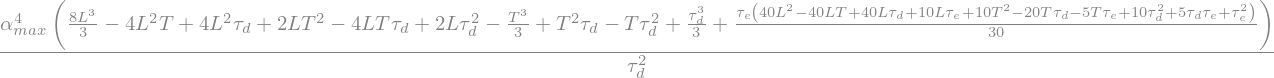

In [9]:
I5a = simplify(integrate(GL * GR_T, (s, -L - te, -L)))
I5b = simplify(integrate(GP * GR_T, (s, -L, L + td - T)))

R5 = simplify(I5a + I5b)
print("R_Gamma for T in [2L + tau_e, 2L + tau_d]:")
display(R5)

## Interval 6: $\ell + \tau_d \leq \tau \leq \ell + \tau_e + \tau_d$

Only the left ramp $\times$ right ramp overlap remains.
The integration domain is $[-L-\tau_e,\, L+\tau_d-\tau]$, with $L+\tau_d-\tau \leq -L$.

$$R_\Gamma(\tau) = \int_{-L-\tau_e}^{L+\tau_d-\tau} \Gamma_L(s)\,\Gamma_R(s+\tau)\,ds$$

Substituting $u = s+L+\tau_e$ and $D = \ell+\tau_e+\tau_d-\tau$:

$$R_\Gamma(\tau) = \frac{\alpha_{\max}^4}{\tau_e^2\,\tau_d^2}\int_0^{D} u^2(D-u)^2\,du
= \frac{\alpha_{\max}^4\,D^5}{30\,\tau_e^2\,\tau_d^2}$$

R_Gamma for T in [2L + tau_d, 2L + tau_e + tau_d]:


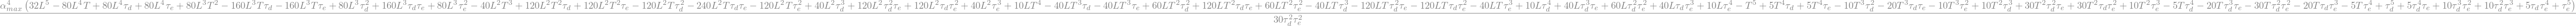


Expected: alpha_max^4 * D^5 / (30 * tau_e^2 * tau_d^2) where D = ell + tau_e + tau_d - T
Match: True


In [10]:
I6 = simplify(integrate(GL * GR_T, (s, -L - te, L + td - T)))

R6 = I6
print("R_Gamma for T in [2L + tau_d, 2L + tau_e + tau_d]:")
display(simplify(R6))

# Verify factored form
D = 2*L + te + td - T
R6_expected = a2**2 * D**5 / (30 * te**2 * td**2)
print(f"\nExpected: alpha_max^4 * D^5 / (30 * tau_e^2 * tau_d^2) where D = ell + tau_e + tau_d - T")
print(f"Match: {simplify(R6 - R6_expected) == 0}")

## Continuity Checks

Verify that $R_\Gamma$ is continuous at each interval boundary.

In [11]:
boundaries = [
    ("T = tau_e",       te,           R1, R2),
    ("T = tau_d",       td,           R2, R3),
    ("T = 2L (= ell)",  2*L,          R3, R4),
    ("T = 2L + tau_e",  2*L + te,     R4, R5),
    ("T = 2L + tau_d",  2*L + td,     R5, R6),
    ("T = 2L+tau_e+tau_d", 2*L+te+td, R6, sp.Integer(0)),
]

print("Continuity checks:")
print("=" * 60)
for label, T_val, R_left, R_right in boundaries:
    val_left = simplify(R_left.subs(T, T_val))
    val_right = simplify(R_right.subs(T, T_val)) if R_right != 0 else sp.Integer(0)
    match = simplify(val_left - val_right) == 0
    print(f"  {label:25s}: match = {match}")
    if not match:
        print(f"    Left:  {val_left}")
        print(f"    Right: {val_right}")
        print(f"    Diff:  {simplify(val_left - val_right)}")

Continuity checks:
  T = tau_e                : match = True
  T = tau_d                : match = True
  T = 2L (= ell)           : match = True


  T = 2L + tau_e           : match = True
  T = 2L + tau_d           : match = True


  T = 2L+tau_e+tau_d       : match = True


## Symmetric Recovery Check

Setting $\tau_e = \tau_d = \tau_s$ should recover the 4-interval result from `derive_R_Gamma.ipynb`.

Symmetric case (tau_e = tau_d = tau_s):

Interval [0, tau_s]:


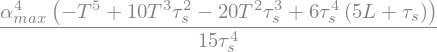


Interval [tau_s, ell] (linear):


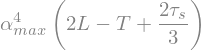

  = alpha_max^4 * (2L + 2*tau_s/3 - T)
  Match: True

Interval [ell, ell+tau_s]:


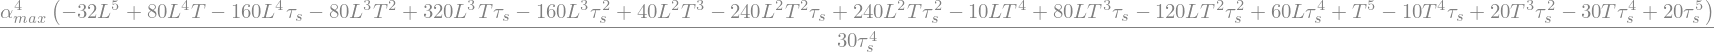


Interval [ell+tau_s, ell+2*tau_s]:


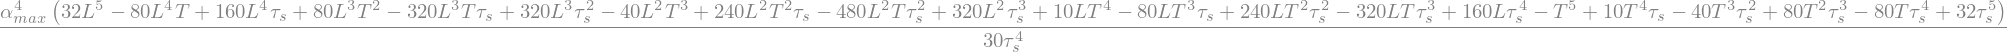

  Expected: alpha_max^4 * (2S-T)^5 / (30*tau_s^4)
  Match: True


In [12]:
ts = sp.Symbol('tau_s', positive=True)
sym_subs = {te: ts, td: ts}

# In the symmetric case, intervals 1-2 merge (since te=td, interval 2 is empty)
# and intervals 5-6 merge (since te=td, interval 5 is empty)
R1_sym = simplify(R1.subs(sym_subs))
R3_sym = simplify(R3.subs(sym_subs))
R4_sym = simplify(R4.subs(sym_subs))
R6_sym = simplify(R6.subs(sym_subs))

print("Symmetric case (tau_e = tau_d = tau_s):")
print("=" * 50)
print("\nInterval [0, tau_s]:")
display(R1_sym)

print("\nInterval [tau_s, ell] (linear):")
display(R3_sym)
print("  = alpha_max^4 * (2L + 2*tau_s/3 - T)")
print(f"  Match: {simplify(R3_sym - a2**2*(2*L + 2*ts/3 - T)) == 0}")

print("\nInterval [ell, ell+tau_s]:")
display(R4_sym)

print("\nInterval [ell+tau_s, ell+2*tau_s]:")
R6_sym_simplified = simplify(R6_sym)
display(R6_sym_simplified)
R6_sym_expected = a2**2 * (2*L + 2*ts - T)**5 / (30 * ts**4)
print(f"  Expected: alpha_max^4 * (2S-T)^5 / (30*tau_s^4)")
print(f"  Match: {simplify(R6_sym_simplified - R6_sym_expected) == 0}")

## Numerical Verification

In [13]:
import numpy as np
import matplotlib.pyplot as plt

def Gamma_asymmetric(s_arr, L_n, te_n, td_n, amax_n):
    """Asymmetric squared trapezoidal envelope centered on the plateau."""
    result = np.zeros_like(s_arr, dtype=float)
    # Left ramp: s in [-L-te, -L]
    left = (s_arr >= -L_n - te_n) & (s_arr < -L_n)
    result[left] = amax_n**2 * ((s_arr[left] + L_n + te_n) / te_n)**2
    # Plateau: s in [-L, L]
    plat = (s_arr >= -L_n) & (s_arr <= L_n)
    result[plat] = amax_n**2
    # Right ramp: s in [L, L+td]
    right = (s_arr > L_n) & (s_arr <= L_n + td_n)
    result[right] = amax_n**2 * ((L_n + td_n - s_arr[right]) / td_n)**2
    return result

def R_Gamma_numerical(tau_arr, L_n, te_n, td_n, amax_n, ns=50000):
    """Numerically compute R_Gamma by direct integration."""
    s_lo = -L_n - te_n - 0.01
    s_hi = L_n + td_n + 0.01
    s_grid = np.linspace(s_lo, s_hi, ns)
    G_s = Gamma_asymmetric(s_grid, L_n, te_n, td_n, amax_n)
    R = np.empty_like(tau_arr)
    for i, t in enumerate(tau_arr):
        G_st = Gamma_asymmetric(s_grid + t, L_n, te_n, td_n, amax_n)
        R[i] = np.trapz(G_s * G_st, s_grid)
    return R

In [14]:
# Test parameters: L=7.5 (ell=15), te=2, td=5, amax=0.1
L_n, te_n, td_n, amax_n = 7.5, 2.0, 5.0, 0.1

# Build symbolic -> numerical evaluator
sym_params = {L: L_n, te: te_n, td: td_n, amax: amax_n}

test_points = [
    (1.0,   "[0, tau_e]",               R1),
    (3.5,   "[tau_e, tau_d]",            R2),
    (10.0,  "[tau_d, ell]",              R3),
    (16.0,  "[ell, ell+tau_e]",          R4),
    (19.0,  "[ell+tau_e, ell+tau_d]",    R5),
    (21.5,  "[ell+tau_d, ell+tau_e+tau_d]", R6),
]

print("Point-by-point verification (L=7.5, te=2, td=5, amax=0.1):")
print("=" * 70)
for T_val, label, R_expr in test_points:
    R_sym_val = float(R_expr.subs(T, T_val).subs(sym_params))
    R_num_val = R_Gamma_numerical(np.array([T_val]), L_n, te_n, td_n, amax_n)[0]
    rel_err = abs(R_sym_val - R_num_val) / max(abs(R_sym_val), 1e-20)
    print(f"  T={T_val:5.1f} {label:35s}: sym={R_sym_val:.10e}, num={R_num_val:.10e}, rel_err={rel_err:.2e}")

Point-by-point verification (L=7.5, te=2, td=5, amax=0.1):
  T=  1.0 [0, tau_e]                         : sym=1.6027863333e-03, num=1.6027863340e-03, rel_err=4.18e-10
  T=  3.5 [tau_e, tau_d]                     : sym=1.3826988333e-03, num=1.3826988349e-03, rel_err=1.13e-09
  T= 10.0 [tau_d, ell]                       : sym=7.3333333333e-04, num=7.3333333495e-04, rel_err=2.20e-09
  T= 16.0 [ell, ell+tau_e]                   : sym=1.3886666667e-04, num=1.3886666731e-04, rel_err=4.62e-09
  T= 19.0 [ell+tau_e, ell+tau_d]             : sym=7.7333333333e-06, num=7.7333333766e-06, rel_err=5.59e-09
  T= 21.5 [ell+tau_d, ell+tau_e+tau_d]       : sym=1.0416666667e-09, num=1.0416666663e-09, rel_err=3.41e-10


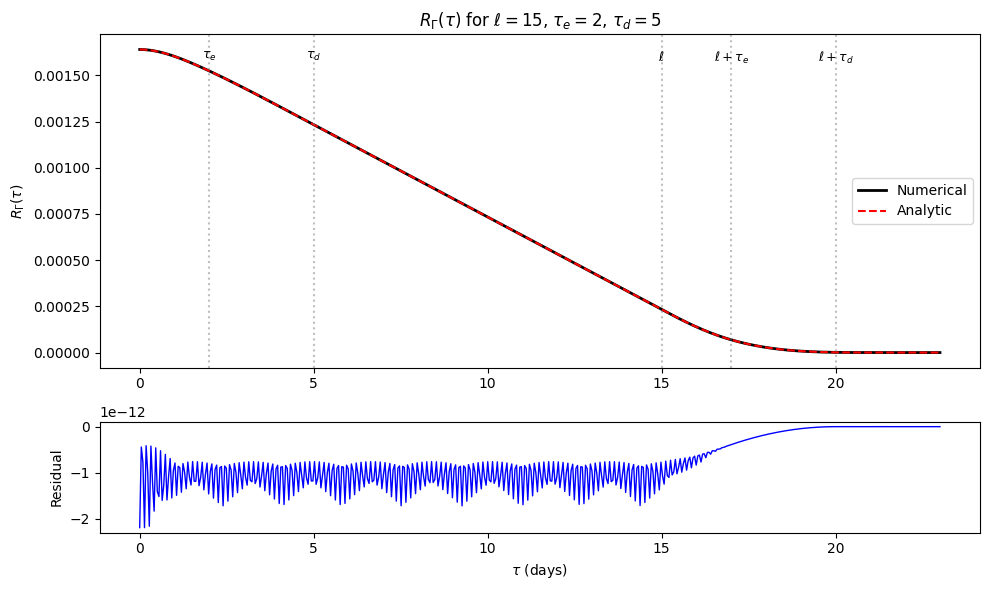

In [15]:
# Plot: analytic vs numerical
tau_plot = np.linspace(0, 2*L_n + te_n + td_n + 1, 500)
R_num = R_Gamma_numerical(tau_plot, L_n, te_n, td_n, amax_n)

# Piecewise analytic evaluation
def R_Gamma_analytic(tau_arr, L_n, te_n, td_n, amax_n):
    p = {L: L_n, te: te_n, td: td_n, amax: amax_n}
    bounds = [0, te_n, td_n, 2*L_n, 2*L_n+te_n, 2*L_n+td_n, 2*L_n+te_n+td_n]
    pieces = [R1, R2, R3, R4, R5, R6]
    result = np.zeros_like(tau_arr)
    for i, R_expr in enumerate(pieces):
        mask = (tau_arr >= bounds[i]) & (tau_arr <= bounds[i+1])
        for j in np.where(mask)[0]:
            result[j] = float(R_expr.subs(T, tau_arr[j]).subs(p))
    return result

R_ana = R_Gamma_analytic(tau_plot, L_n, te_n, td_n, amax_n)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), gridspec_kw={'height_ratios': [3, 1]})

ax = axes[0]
ax.plot(tau_plot, R_num, 'k-', lw=2, label='Numerical')
ax.plot(tau_plot, R_ana, 'r--', lw=1.5, label='Analytic')
# Mark interval boundaries
for b, lbl in [(te_n, r'$\tau_e$'), (td_n, r'$\tau_d$'), (2*L_n, r'$\ell$'),
               (2*L_n+te_n, r'$\ell+\tau_e$'), (2*L_n+td_n, r'$\ell+\tau_d$')]:
    ax.axvline(b, color='gray', ls=':', alpha=0.5)
    ax.text(b, ax.get_ylim()[1]*0.95 if ax.get_ylim()[1] > 0 else 0, lbl,
            ha='center', va='top', fontsize=9)
ax.set_ylabel(r'$R_\Gamma(\tau)$')
ax.set_title(rf'$R_\Gamma(\tau)$ for $\ell={2*L_n:.0f}$, $\tau_e={te_n:.0f}$, $\tau_d={td_n:.0f}$')
ax.legend()

ax2 = axes[1]
residual = R_ana - R_num
ax2.plot(tau_plot, residual, 'b-', lw=1)
ax2.set_xlabel(r'$\tau$ (days)')
ax2.set_ylabel('Residual')
ax2.ticklabel_format(style='scientific', axis='y', scilimits=(-3,3))

plt.tight_layout()
plt.show()

## Second Test: Highly Asymmetric Case

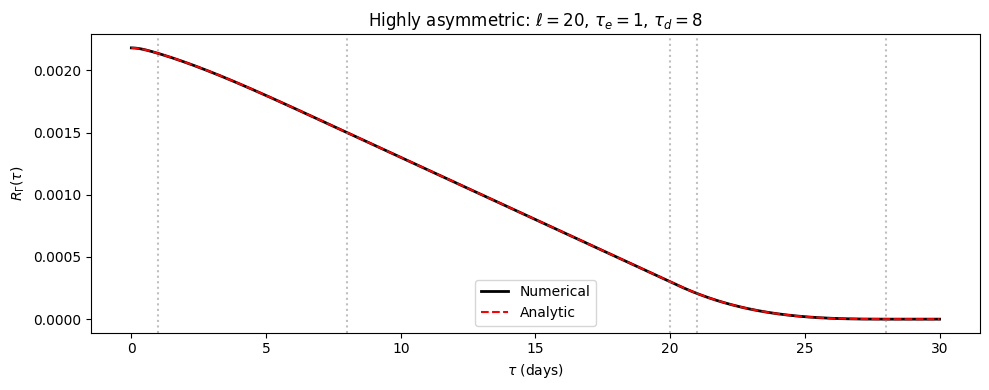

Max absolute residual: 4.81e-12


In [16]:
# Extreme asymmetry: te=1, td=8, ell=20
L_n2, te_n2, td_n2, amax_n2 = 10.0, 1.0, 8.0, 0.1

tau_plot2 = np.linspace(0, 2*L_n2 + te_n2 + td_n2 + 1, 500)
R_num2 = R_Gamma_numerical(tau_plot2, L_n2, te_n2, td_n2, amax_n2)
R_ana2 = R_Gamma_analytic(tau_plot2, L_n2, te_n2, td_n2, amax_n2)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(tau_plot2, R_num2, 'k-', lw=2, label='Numerical')
ax.plot(tau_plot2, R_ana2, 'r--', lw=1.5, label='Analytic')
for b, lbl in [(te_n2, r'$\tau_e$'), (td_n2, r'$\tau_d$'), (2*L_n2, r'$\ell$'),
               (2*L_n2+te_n2, r'$\ell+\tau_e$'), (2*L_n2+td_n2, r'$\ell+\tau_d$')]:
    ax.axvline(b, color='gray', ls=':', alpha=0.5)
ax.set_xlabel(r'$\tau$ (days)')
ax.set_ylabel(r'$R_\Gamma(\tau)$')
ax.set_title(rf'Highly asymmetric: $\ell={2*L_n2:.0f}$, $\tau_e={te_n2:.0f}$, $\tau_d={td_n2:.0f}$')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Max absolute residual: {np.max(np.abs(R_ana2 - R_num2)):.2e}")

## Convert to Physical Parameters

Express all six intervals in terms of $\ell$, $\tau_e$, $\tau_d$ (substituting $L = \ell/2$).

In [17]:
ell = sp.Symbol('ell', positive=True)
phys_subs = {L: ell / 2}

labels = [
    r"0 \leq \tau \leq \tau_e",
    r"\tau_e \leq \tau \leq \tau_d",
    r"\tau_d \leq \tau \leq \ell",
    r"\ell \leq \tau \leq \ell + \tau_e",
    r"\ell + \tau_e \leq \tau \leq \ell + \tau_d",
    r"\ell + \tau_d \leq \tau \leq \ell + \tau_e + \tau_d",
]

print("CLOSED-FORM R_Gamma(tau) — Asymmetric Trapezoidal Envelope")
print("(assuming tau_e <= tau_d < ell)")
print("=" * 60)
for label, R_expr in zip(labels, [R1, R2, R3, R4, R5, R6]):
    R_phys = simplify(R_expr.subs(phys_subs))
    print(f"\n  {label}:")
    display(Math(rf"R_\Gamma(\tau) = {latex(R_phys)}"))

print(f"\n  tau > ell + tau_e + tau_d:  R_Gamma = 0")

CLOSED-FORM R_Gamma(tau) — Asymmetric Trapezoidal Envelope
(assuming tau_e <= tau_d < ell)

  0 \leq \tau \leq \tau_e:


<IPython.core.display.Math object>


  \tau_e \leq \tau \leq \tau_d:


<IPython.core.display.Math object>


  \tau_d \leq \tau \leq \ell:


...


  \ell + \tau_e \leq \tau \leq \ell + \tau_d:


<IPython.core.display.Math object>


  \ell + \tau_d \leq \tau \leq \ell + \tau_e + \tau_d:


<IPython.core.display.Math object>


  tau > ell + tau_e + tau_d:  R_Gamma = 0


## Summary

For a trapezoidal envelope with emergence timescale $\tau_e$ and decay timescale $\tau_d$
(where $\tau_e \leq \tau_d$ WLOG):

1. **$R_\Gamma$ has compact support** $[0,\, \ell + \tau_e + \tau_d]$, generalizing
   $[0,\, \ell + 2\tau_s]$ from the symmetric case.

2. **The linear regime** $[\tau_d,\, \ell]$ gives
   $R_\Gamma(\tau) = \alpha_{\max}^4(\ell + (\tau_e+\tau_d)/3 - \tau)$,
   with slope $-\alpha_{\max}^4$ independent of the ramp timescales.

3. **The tail** $[\ell+\tau_d,\, \ell+\tau_e+\tau_d]$ factors as
   $R_\Gamma = \alpha_{\max}^4 D^5 / (30\,\tau_e^2\tau_d^2)$
   where $D = \ell + \tau_e + \tau_d - \tau$.

4. **DC value:** $R_\Gamma(0) = \alpha_{\max}^4(\ell + 2\tau_e/5 + 2\tau_d/5)$.

5. **Symmetry:** $R_\Gamma(\tau;\tau_e,\tau_d) = R_\Gamma(\tau;\tau_d,\tau_e)$ — swapping
   emergence and decay does not change the autocorrelation.

6. **Six intervals** reduce to four when $\tau_e = \tau_d$, recovering the symmetric result.